In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
caminho_arquivo = '/content/drive/MyDrive/Visualização/Visualização/states_all/states_all.csv'

In [ ]:
df = pd.read_csv(caminho_arquivo)

In [ ]:
df.columns

Index(['PRIMARY_KEY', 'STATE', 'YEAR', 'ENROLL', 'TOTAL_REVENUE',
       'FEDERAL_REVENUE', 'STATE_REVENUE', 'LOCAL_REVENUE',
       'TOTAL_EXPENDITURE', 'INSTRUCTION_EXPENDITURE',
       'SUPPORT_SERVICES_EXPENDITURE', 'OTHER_EXPENDITURE',
       'CAPITAL_OUTLAY_EXPENDITURE', 'GRADES_PK_G', 'GRADES_KG_G',
       'GRADES_4_G', 'GRADES_8_G', 'GRADES_12_G', 'GRADES_1_8_G',
       'GRADES_9_12_G', 'GRADES_ALL_G', 'AVG_MATH_4_SCORE', 'AVG_MATH_8_SCORE',
       'AVG_READING_4_SCORE', 'AVG_READING_8_SCORE'],
      dtype='object')

In [ ]:
colunas_foco = ['STATE', 'TOTAL_REVENUE', 'TOTAL_EXPENDITURE', 'AVG_MATH_4_SCORE', 'AVG_READING_4_SCORE']

In [ ]:
df['YEAR'].value_counts()

,count
YEAR,
1992,53
1994,53
1996,53
2000,53
1998,53
2005,53
2007,53
2003,53
2002,53


In [ ]:
df_2015 = df[df['YEAR'] == 2015].dropna(subset=colunas_foco).copy()

In [ ]:
df_2015.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
1173,2015_ALABAMA,ALABAMA,2015,734974.0,7360222.0,795238.0,4080167.0,2484817.0,7501799.0,3817479.0,...,55808.0,55792.0,50668.0,452764.0,222182.0,743789.0,231.0,267.0,217.0,259.0
1174,2015_ALASKA,ALASKA,2015,130755.0,2920986.0,344111.0,2026555.0,550320.0,2968341.0,1484610.0,...,10118.0,9400.0,9651.0,80011.0,38688.0,132477.0,236.0,280.0,213.0,260.0
1175,2015_ARIZONA,ARIZONA,2015,944978.0,8230507.0,1093834.0,3232013.0,3904660.0,7902600.0,3846357.0,...,86594.0,84084.0,84854.0,687144.0,333579.0,1109040.0,238.0,283.0,215.0,263.0
1176,2015_ARKANSAS,ARKANSAS,2015,479682.0,5308625.0,581412.0,4075118.0,652095.0,5350543.0,2620399.0,...,35893.0,36882.0,32385.0,296050.0,142242.0,492132.0,235.0,275.0,218.0,259.0
1177,2015_CALIFORNIA,CALIFORNIA,2015,6226523.0,78248042.0,7556365.0,42360470.0,28331207.0,78365958.0,38951948.0,...,485885.0,465322.0,492835.0,3748465.0,1941009.0,6226737.0,232.0,275.0,213.0,259.0


In [ ]:
df_2015['NIVEL_MATH'] = pd.cut(
    df_2015['AVG_MATH_4_SCORE'],
    bins=[0, 235, 243, 300],
    labels=['Baixo', 'Médio', 'Alto']
)

In [ ]:
coluna_ordenacao = 'TOTAL_REVENUE'

df_sorted = df_2015.sort_values(by=coluna_ordenacao, ascending=True).reset_index(drop=True)

In [ ]:
colunas_vis = ['STATE', 'NIVEL_MATH', 'TOTAL_REVENUE', 'TOTAL_EXPENDITURE', 'AVG_MATH_4_SCORE']
tipos_vis = ['nominal', 'ordinal', 'quantitativa', 'quantitativa', 'quantitativa']

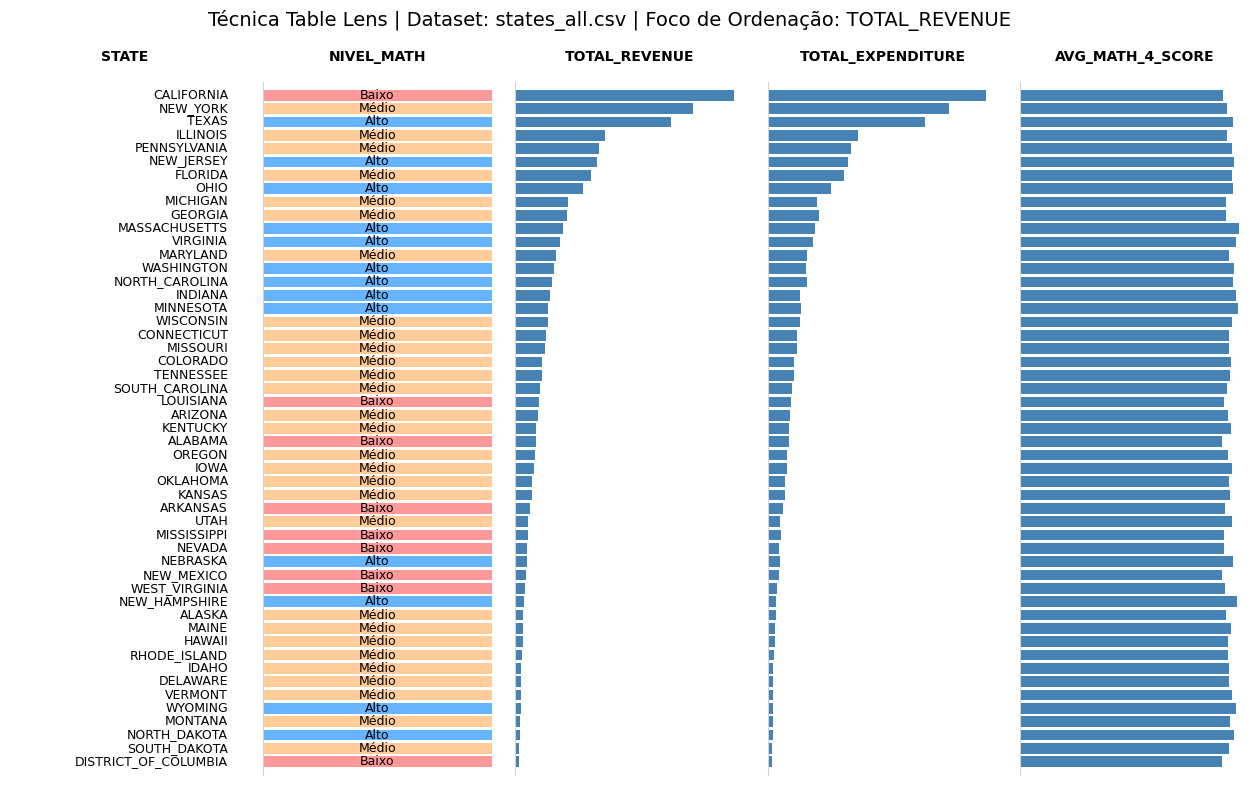

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(colunas_vis), figsize=(16, 9), sharey=True)
plt.subplots_adjust(wspace=0.1) # Espaçamento pequeno entre as colunas
y_pos = np.arange(len(df_sorted))

cores_ordinais = {'Baixo': '#ff9999', 'Médio': '#ffcc99', 'Alto': '#66b3ff'}

for i, (col, tipo) in enumerate(zip(colunas_vis, tipos_vis)):
    ax = axes[i]

    if tipo == 'quantitativa':
        # Variáveis quantitativas usam o comprimento da barra
        ax.barh(y_pos, df_sorted[col], color='steelblue', height=0.8)
        ax.set_xticks([]) # Remove o eixo X numérico para focar no visual

    elif tipo == 'ordinal':
        # Variáveis ordinais usam intensidade de cor. Desenhamos blocos do mesmo tamanho.
        cores = df_sorted[col].map(cores_ordinais).tolist()
        ax.barh(y_pos, [1]*len(df_sorted), color=cores, height=0.8)
        ax.set_xticks([])
        ax.set_xlim(0, 1)
        # Inserimos o texto dentro do bloco de cor
        for j, val in enumerate(df_sorted[col]):
            ax.text(0.5, j, str(val), ha='center', va='center', fontsize=9, color='black')

    elif tipo == 'nominal':
            # Variáveis nominais: colocamos o texto dentro da área de plotagem para preencher a coluna
            ax.barh(y_pos, [1]*len(df_sorted), color='white') # Fundo invisível
            ax.set_xticks([])
            ax.set_yticks([]) # Removemos os eixos/tracinhos feios que ficavam para fora
            ax.set_xlim(0, 1)

            # Nome do estado alinhado à direita, preenchendo a coluna
            for j, val in enumerate(df_sorted[col]):
                ax.text(0.95, j, str(val), ha='right', va='center', fontsize=9, color='black')

            ax.spines['left'].set_visible(False)

    # Títulos e limpeza das bordas para parecer uma tabela
    ax.set_title(col, fontsize=10, fontweight='bold', pad=15)
    ax.set_ylim(-1, len(df_sorted))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if tipo != 'nominal':
        ax.spines['left'].set_color('lightgray')

# Título do Table lens
plt.suptitle(f'Table Lens | Dataset: states_all.csv |Ordenado por: {coluna_ordenacao}', fontsize=14, y=0.96)

# Salvar a imagem com alta resolução para o relatório
plt.savefig('table_lens_resultado.png', dpi=300, bbox_inches='tight')

plt.show()